<a href="https://colab.research.google.com/github/taeheeheat/I310D_Group_FinalProject/blob/main/Data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Loading data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/I310D_project/AustinAnimalCenter_27Mar5pm.csv'
df = pd.read_csv(file_path)

display(df.head())

Mounted at /content/drive


,outcome_status,euthanasia_reason,name,type,sex,animal_id,primary_breed,primary_color,secondary_color,timestamp,spayed_neutered,outcome_date,id,intake_date,days_in_shelter,date_of_birth
0,Transfer Out,NaN,NaN,Cat,Male,8667,Domestic Shorthair,Black,Grey,2026-03-12T12:34:54.000,No,2025-05-31T19:01:00,18126,2025-05-31T13:31:00.000,285,2025-05-01T00:00:00.000
1,Adopted,NaN,Leona,Cat,Female,6994,Domestic Shorthair,Brown Tabby,NaN,2026-03-12T12:34:55.000,Yes,2025-05-25T15:40:30,16939,2025-05-06T12:35:00.000,310,2022-05-06T00:00:00.000
2,Adopted,NaN,*NEBULA,Cat,Male,6675,Domestic Medium Hair,Black,Black,2026-03-12T12:34:57.000,Yes,2025-05-17T16:13:00,15505,2025-04-24T00:00:00.000,322,2015-04-24T00:00:00.000
3,Transfer Out,NaN,NaN,Cat,Female,8392,Domestic Shorthair,Tortoiseshell,NaN,2026-03-12T12:34:54.000,Unknown,2025-05-29T15:16:00,17624,2025-05-28T12:03:00.000,288,2025-05-17T00:00:00.000
4,Unassisted Death - In Foster,NaN,Dewdrop,Kitten,Unknown,7065,Domestic Shorthair,Grey,Orange Tabby,2026-03-12T12:34:57.000,Unknown,2025-05-13T14:09:00,14631,2025-05-07T12:45:00.000,309,2025-04-02T00:00:00.000


# Step 2: Data Cleaning & Preprocessing

In [ ]:
# 1. Create the target variable (1 if 'Adopted', 0 for everything else)
df['Is_Adopted'] = df['outcome_status'].apply(lambda x: 1 if x == 'Adopted' else 0)

# 2. Handle missing values
# Drop rows without an outcome_status since we can't train the model on them
df = df.dropna(subset=['outcome_status'])

# Fill missing name, sex, and spayed/neutered status with 'Unknown'
df['name'] = df['name'].fillna('Unknown')
df['sex'] = df['sex'].fillna('Unknown')
df['spayed_neutered'] = df['spayed_neutered'].fillna('Unknown')

# 3. Filter the data
# We only keep 'Dog' and 'Cat' to make our analysis clear and simple
df = df[df['type'].isin(['Dog', 'Cat'])]

print("Data cleaning done! Total rows now:", len(df))
display(df[['type', 'sex', 'spayed_neutered', 'days_in_shelter', 'outcome_status', 'Is_Adopted']].head())

데이터 전처리 완료! 현재 데이터 수: 18436


,type,sex,spayed_neutered,days_in_shelter,outcome_status,Is_Adopted
0,Cat,Male,No,285,Transfer Out,0
1,Cat,Female,Yes,310,Adopted,1
2,Cat,Male,Yes,322,Adopted,1
3,Cat,Female,Unknown,288,Transfer Out,0
5,Cat,Female,Yes,300,Adopted,1


# Step 3: Exploratory Data Analysis (EDA)

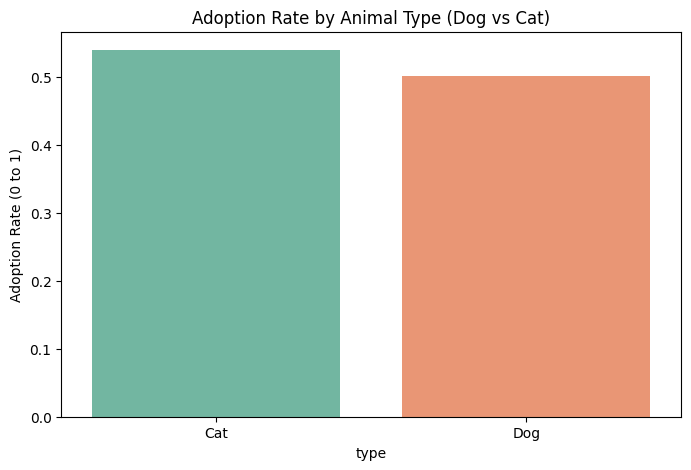

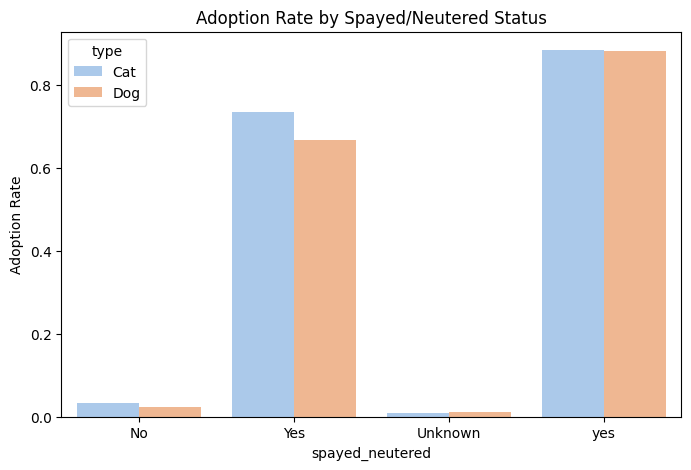

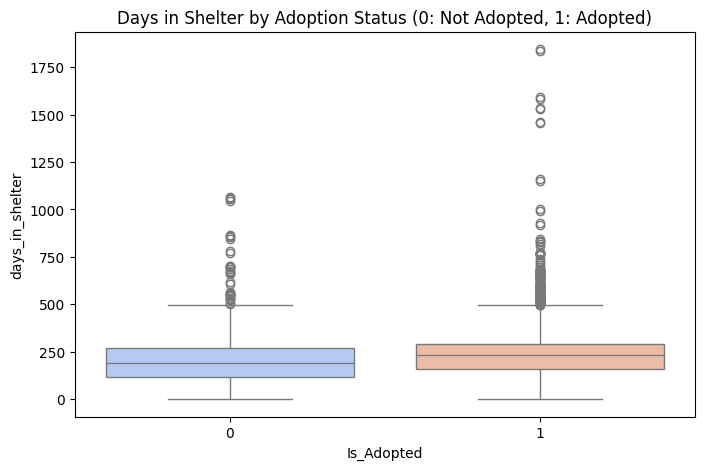

In [ ]:
# Convert 'days_in_shelter' to numeric for the third plot
df['days_in_shelter'] = pd.to_numeric(df['days_in_shelter'], errors='coerce')

# 1. Compare adoption rates by animal type (Dog vs. Cat)
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='type', y='Is_Adopted', hue='type', errorbar=None, palette='Set2', legend=False)
plt.title('Adoption Rate by Animal Type (Dog vs Cat)')
plt.ylabel('Adoption Rate (0 to 1)')
plt.show()

# 2. Compare adoption rates based on spayed/neutered status
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='spayed_neutered', y='Is_Adopted', hue='type', errorbar=None, palette='pastel')
plt.title('Adoption Rate by Spayed/Neutered Status')
plt.ylabel('Adoption Rate')
plt.show()

# 3. Analyze the distribution of days spent in the shelter by adoption status
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Is_Adopted', y='days_in_shelter', hue='Is_Adopted', palette='coolwarm', legend=False)
plt.title('Days in Shelter by Adoption Status (0: Not Adopted, 1: Adopted)')
plt.show()

# Step 4: Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Feature selection and One-Hot Encoding
# Convert categorical text data into numerical format (0s and 1s)
features = ['type', 'sex', 'spayed_neutered']
X = pd.get_dummies(df[features], drop_first=True)
y = df['Is_Adopted']

# 2. Split data into Training and Testing sets (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 4. Prediction and Model Performance Evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Overall model accuracy: {accuracy:.3f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Overall model accuracy: 0.810

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.62      0.76      1775
           1       0.74      0.98      0.84      1913

    accuracy                           0.81      3688
   macro avg       0.86      0.80      0.80      3688
weighted avg       0.85      0.81      0.80      3688



# Step 5: Human-Centered Data Science (HCDS) - Fairness Audit

--- Fairness Evaluation by Animal Type ---
Group: Dog | Accuracy: 0.776
Group: Cat | Accuracy: 0.833


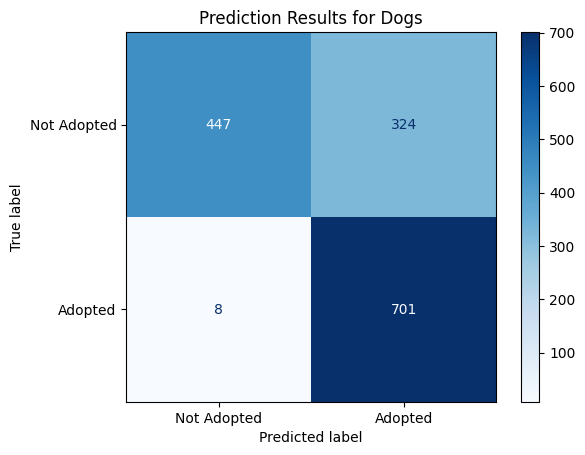

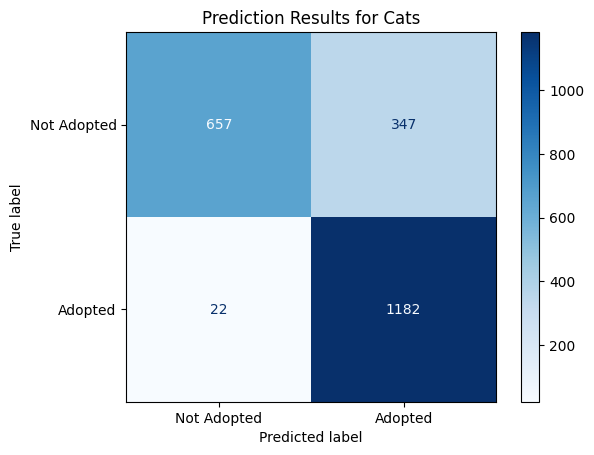

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Add our predictions to the test data to compare them
results_df = X_test.copy()
results_df['Actual_Adopted'] = y_test
results_df['Predicted_Adopted'] = y_pred

# Change the one-hot encoded column back to text to make it readable
# 'type_Dog' is 1 if it's a dog, 0 if it's a cat
results_df['Animal_Type'] = results_df['type_Dog'].apply(lambda x: 'Dog' if x == 1 else 'Cat')

print("--- Fairness Evaluation by Animal Type ---")

# Check the accuracy separately for dogs and cats
for animal in ['Dog', 'Cat']:
    subgroup = results_df[results_df['Animal_Type'] == animal]
    acc = accuracy_score(subgroup['Actual_Adopted'], subgroup['Predicted_Adopted'])
    print(f"Group: {animal} | Accuracy: {acc:.3f}")

# Visualize fairness using a confusion matrix for each group
for animal in ['Dog', 'Cat']:
    subgroup = results_df[results_df['Animal_Type'] == animal]
    cm = confusion_matrix(subgroup['Actual_Adopted'], subgroup['Predicted_Adopted'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Adopted', 'Adopted'])
    disp.plot(cmap='Blues')
    plt.title(f'Prediction Results for {animal}s')
    plt.show()